# Restaurant Growth Momentum Analysis
## Marketing Investment Optimization

This notebook identifies restaurants with the highest growth potential and provides data-driven recommendations for marketing resource allocation.

### Key Questions Answered:
1. Which restaurants are gaining momentum?
2. Which restaurants have the highest growth potential?
3. Where should marketing resources be focused for maximum ROI?

### Analysis Approach:
- **Time-series analysis** to identify growth trends
- **Segment classification** based on volume and growth
- **Momentum scoring** to prioritize marketing investments
- **Actionable recommendations** for each segment

In [1]:
# Import the analysis module
import sys
sys.path.append('/home/claude')

from restaurant_growth_analysis import run_growth_analysis
import pandas as pd
import matplotlib.pyplot as plt

# If you want to run specific functions separately:
from restaurant_growth_analysis import (
    prepare_data,
    calculate_time_series_metrics,
    calculate_growth_rates,
    create_growth_summary,
    identify_growth_segments,
    
    plot_growth_matrix,
    plot_trend_analysis,
    generate_marketing_recommendations,
    create_summary_report
)

## Step 1: Load Your Data

Load your restaurant booking dataframe. The analysis expects columns like:
- `booking_date`: Date of the booking
- `restaurant_id`: Unique restaurant identifier
- `name`: Restaurant name
- `revenue_baht`: Revenue amount
- `total_guests`: Number of guests
- `adult`, `kids`: Guest breakdown
- `no_show`: Whether customer showed up
- `is_outlier`: Outlier flag (optional)

In [2]:
# Load your dataframe
# Replace 'your_data.csv' with your actual data source
output_file = "C:/Users/foogu/Downloads/df_filtered.csv"
df = pd.read_csv(output_file)

In [3]:
# For this example, assuming df is already loaded in your environment
# Check the dataframe
print(f"Dataset shape: {df.shape}")
print(f"\nColumns available:")
print(df.columns.tolist())
print(f"\nDate range: {df['booking_date'].min()} to {df['booking_date'].max()}")
print(f"Unique restaurants: {df['restaurant_id'].nunique()}")

Dataset shape: (3241929, 33)

Columns available:
['has_shopee_pay', 'has_special_request', 'medium', 'name', 'guest_id_masked', 'adult', 'id', 'restaurant_id', 'active', 'is_temporary', 'for_locking_system', 'no_show', 'arrived', 'channel', 'kids', 'user_id_masked', 'date', 'prepared', 'ack', 'created_at', 'refund', 'adjusted', 'revenue_baht', 'booking_date', 'booking_weekday_name', 'end_time_str', 'start_time_str', 'invalid_time', 'is_outlier', 'outlier_reason', 'total_guests', 'revenue_per_guest', 'is_star']

Date range: 2024-01-19 to 2026-12-31
Unique restaurants: 3653


In [4]:
# Copy and paste this code into your notebook/script:

print("CHECKING YOUR COLUMNS")
print("=" * 80)
print("\nYour columns are:")
print(df.columns.tolist())
print()

# Check required columns
required_cols = ['booking_date', 'restaurant_id', 'name', 'revenue_baht', 'total_guests', 'id']

print("Checking for required columns:")
for col in required_cols:
    if col in df.columns:
        print(f"✓ {col} - FOUND")
    else:
        print(f"✗ {col} - NOT FOUND (you need to map this)")
print()

# Show a sample of your data
print("\nFirst few rows of your data:")
print(df.head(3))

CHECKING YOUR COLUMNS

Your columns are:
['has_shopee_pay', 'has_special_request', 'medium', 'name', 'guest_id_masked', 'adult', 'id', 'restaurant_id', 'active', 'is_temporary', 'for_locking_system', 'no_show', 'arrived', 'channel', 'kids', 'user_id_masked', 'date', 'prepared', 'ack', 'created_at', 'refund', 'adjusted', 'revenue_baht', 'booking_date', 'booking_weekday_name', 'end_time_str', 'start_time_str', 'invalid_time', 'is_outlier', 'outlier_reason', 'total_guests', 'revenue_per_guest', 'is_star']

Checking for required columns:
✓ booking_date - FOUND
✓ restaurant_id - FOUND
✓ name - FOUND
✓ revenue_baht - FOUND
✓ total_guests - FOUND
✓ id - FOUND


First few rows of your data:
   has_shopee_pay  has_special_request medium name guest_id_masked  adult  \
0             0.0                  0.0    Web  NaN                      2   
1             0.0                  1.0    Web  NaN                      2   
2             NaN                  NaN    NaN  NaN                      1   


In [5]:
df.columns
# identify the user_id which display multiple transactions of the same restaurant with the same created_at date and only retain the first record
# assume these records are duplicates, remove them, then run the analysis


Index(['has_shopee_pay', 'has_special_request', 'medium', 'name',
       'guest_id_masked', 'adult', 'id', 'restaurant_id', 'active',
       'is_temporary', 'for_locking_system', 'no_show', 'arrived', 'channel',
       'kids', 'user_id_masked', 'date', 'prepared', 'ack', 'created_at',
       'refund', 'adjusted', 'revenue_baht', 'booking_date',
       'booking_weekday_name', 'end_time_str', 'start_time_str',
       'invalid_time', 'is_outlier', 'outlier_reason', 'total_guests',
       'revenue_per_guest', 'is_star'],
      dtype='object')

## Step 2: Run Complete Analysis

This single function will:
1. Prepare and clean the data
2. Calculate monthly metrics and growth rates
3. Classify restaurants into segments
4. Generate visualizations
5. Create marketing recommendations
6. Export all results

In [5]:
import os 
# OPTION 1: Quick one-liner fix
df['booking_date'] = pd.to_datetime(df['booking_date'].astype(str), format='%Y-%m-%d', errors='coerce')

from preprocessing_helpers import prepare_data_for_analysis
from restaurant_growth_analysis_adjustable import GrowthAnalysisConfig, run_growth_analysis_adjustable

# STEP 1: Clean your data (removes future bookings + shows date info)
df_clean, info = prepare_data_for_analysis(df, date_column='booking_date')

# STEP 2: Configure for 6-month analysis
config = GrowthAnalysisConfig()
config.recent_months = 6              # Look back 6 months (not 3)
config.min_monthly_bookings = 5       # Filter low-volume months
config.high_volume_threshold = 15     # Adjust to your market
config.high_growth_threshold = 10      # 10%+ = "high growth"
config.weight_volume = 0.4           # 60% current volume
config.weight_booking_growth = 0.3   # 20% booking growth
config.weight_revenue_growth = 0.3   # 20% revenue growth


# Create an output directory on your system
output_dir = r'C:\Users\foogu\OneDrive\Documents\IS455 Data Analytics in Asia'  # Change this path!
os.makedirs(output_dir, exist_ok=True)

# STEP 3: Run analysis
restaurant_summary, monthly_metrics, recommendations = run_growth_analysis_adjustable(
    df_clean,
    output_dir=output_dir,
    config=config)

FILTERING FUTURE BOOKINGS
Today's date: 2026-01-28
Original data range: 2024-01-19 to 2026-12-31
Future bookings found: 5,661 (0.2%)
Filtered data range: 2024-01-19 to 2026-01-28
Records remaining: 3,236,268
DATE RANGE ANALYSIS
Date range: 2024-01-19 to 2026-01-28
Total span: 740 days (24.3 months)
Unique months with data: 25
Average bookings per month: 129451

Monthly booking counts:
  2024-01: 22,201 bookings
  2024-02: 150,369 bookings
  2024-03: 170,775 bookings
  2024-04: 188,109 bookings
  2024-05: 82,642 bookings
  2024-06: 301,381 bookings
  2024-07: 298,747 bookings
  2024-08: 265,544 bookings
  2024-09: 228,730 bookings
  2024-10: 55,738 bookings
  2024-11: 98,973 bookings
  2024-12: 207,079 bookings
  2025-01: 213,727 bookings
  2025-02: 197,978 bookings
  2025-03: 125,719 bookings
  2025-04: 55,698 bookings
  2025-05: 49,073 bookings
  2025-06: 56,748 bookings
  2025-07: 60,476 bookings
  2025-08: 66,780 bookings
  2025-09: 57,503 bookings
  2025-10: 58,288 bookings
  2025-

## Step 3: Explore Results

### Restaurant Summary by Segment

In [6]:
# View top momentum restaurants
print("TOP 20 RESTAURANTS BY MOMENTUM SCORE")
print("=" * 100)

top_20 = restaurant_summary.nlargest(20, 'momentum_score')[[
    'name', 'segment', 'momentum_score', 'avg_growth_rate', 
    'revenue_growth_rate', 'recent_avg_bookings', 'recent_avg_revenue'
]]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)

display(top_20)

TOP 20 RESTAURANTS BY MOMENTUM SCORE


,name,segment,momentum_score,avg_growth_rate,revenue_growth_rate,recent_avg_bookings,recent_avg_revenue
579,Copper Beyond Buffet Gayso...,Established Players,73.682357,2.025963,10.248559,5163.285714,2.778485e+06
858,Bubble in the Forest Cafe,Rising Stars,66.238552,64.146251,69.322835,805.285714,3.214911e+05
837,NAMA Japanese and Seafood ...,Rising Stars,64.634724,28.580265,34.067443,2044.714286,9.813017e+05
5,Vertigo Rooftop Banyan Tree,Rising Stars,63.353346,91.050341,98.901321,432.857143,3.075614e+05
418,Cielo Sky Bar & Restaurant...,Rising Stars,63.189553,97.838118,98.379316,411.714286,1.389923e+05
23,Copper Beyond Buffet The S...,Rising Stars,63.179182,10.065444,16.432558,3256.714286,1.382553e+06
1189,Kohaku Omakase,Rising Stars,62.898487,64.931865,63.262110,374.142857,2.383115e+05
1184,Hotaru 119 Omakase - Rama 9,Rising Stars,62.539911,120.606040,113.476649,327.857143,1.538652e+05
10,Bai Yun Banyan Tree Bangkok,Rising Stars,62.073984,200.436168,229.035004,267.714286,9.683847e+04
1335,Kisekhi Craft and Fusion B...,Rising Stars,61.944498,1446.967567,1000.127967,251.000000,4.592390e+04


In [7]:
# Segment breakdown
print("\nRESTAURANT SEGMENTS BREAKDOWN")
print("=" * 100)

segment_stats = restaurant_summary.groupby('segment').agg({
    'restaurant_id': 'count',
    'avg_growth_rate': 'mean',
    'revenue_growth_rate': 'mean',
    'recent_avg_bookings': 'mean',
    'recent_avg_revenue': 'mean',
    'momentum_score': 'mean'
}).round(2)

segment_stats.columns = ['Count', 'Avg Booking Growth %', 'Avg Revenue Growth %', 
                         'Avg Monthly Bookings', 'Avg Monthly Revenue', 'Avg Momentum Score']

display(segment_stats)


RESTAURANT SEGMENTS BREAKDOWN


,Count,Avg Booking Growth %,Avg Revenue Growth %,Avg Monthly Bookings,Avg Monthly Revenue,Avg Momentum Score
segment,,,,,,
Emerging Opportunities,430,81.05,110.34,9.95,2530.49,52.84
Established Players,292,-18.75,-11.50,117.38,39751.15,23.15
Needs Attention,533,-14.46,-0.88,7.78,1636.82,25.22
Rising Stars,463,114.27,163.77,65.34,23888.96,55.92


### Rising Stars - Highest Priority for Marketing Investment

In [8]:
# Focus on Rising Stars
rising_stars = restaurant_summary[restaurant_summary['segment'] == 'Rising Stars'].nlargest(15, 'momentum_score')

print("RISING STARS - INVEST HEAVILY")
print("=" * 100)
print("These restaurants show HIGH volume AND HIGH growth - your best marketing investments\n")

display(rising_stars[[
    'name', 'momentum_score', 'avg_growth_rate', 'revenue_growth_rate',
    'recent_avg_bookings', 'total_bookings', 'total_revenue'
]])

RISING STARS - INVEST HEAVILY
These restaurants show HIGH volume AND HIGH growth - your best marketing investments



,name,momentum_score,avg_growth_rate,revenue_growth_rate,recent_avg_bookings,total_bookings,total_revenue
858,Bubble in the Forest Cafe,66.238552,64.146251,69.322835,805.285714,11526,4.340827e+06
837,NAMA Japanese and Seafood ...,64.634724,28.580265,34.067443,2044.714286,25590,1.219383e+07
5,Vertigo Rooftop Banyan Tree,63.353346,91.050341,98.901321,432.857143,19255,1.332212e+07
418,Cielo Sky Bar & Restaurant...,63.189553,97.838118,98.379316,411.714286,16042,7.432908e+06
23,Copper Beyond Buffet The S...,63.179182,10.065444,16.432558,3256.714286,367489,1.775460e+08
1189,Kohaku Omakase,62.898487,64.931865,63.262110,374.142857,2841,1.825049e+06
1184,Hotaru 119 Omakase - Rama 9,62.539911,120.606040,113.476649,327.857143,2578,1.195977e+06
10,Bai Yun Banyan Tree Bangkok,62.073984,200.436168,229.035004,267.714286,3487,1.262811e+06
1335,Kisekhi Craft and Fusion B...,61.944498,1446.967567,1000.127967,251.000000,1506,2.755434e+05
1207,Lamaya Bangkok,61.498492,105.116017,108.524265,193.428571,1399,4.330008e+05


### Emerging Opportunities - Scale Up Marketing

In [9]:
# Emerging opportunities
emerging = restaurant_summary[restaurant_summary['segment'] == 'Emerging Opportunities'].nlargest(15, 'momentum_score')

print("EMERGING OPPORTUNITIES - SCALE UP")
print("=" * 100)
print("High growth but lower volume - invest to convert momentum into market share\n")

display(emerging[[
    'name', 'momentum_score', 'avg_growth_rate', 'revenue_growth_rate',
    'recent_avg_bookings', 'total_bookings', 'total_revenue'
]])

EMERGING OPPORTUNITIES - SCALE UP
High growth but lower volume - invest to convert momentum into market share



,name,momentum_score,avg_growth_rate,revenue_growth_rate,recent_avg_bookings,total_bookings,total_revenue
1490,Waa Cow! Vivocity,60.113106,83.888889,124.862675,14.600000,73,1024.80
114,Hong Kong Fisherman,60.112332,59.444444,105.391738,14.500000,113,39513.60
641,Jharokha by Indus,60.112332,110.000000,661.836171,14.500000,101,73581.60
817,Bonus shabu,60.112332,283.333333,276.674622,14.500000,29,3595.08
902,RedTail Bar by Zouk,60.112332,78.373016,325.021938,14.500000,43,1016.28
979,LUNA 48 Rooftop Bar at Ram...,60.112332,105.976431,146.874006,14.500000,132,23780.25
1246,The White Tiffin (Woods Sq...,60.112332,122.222222,190.784044,14.500000,29,340.92
1547,Allora Ristorante and Bar,60.112332,88.723545,88.277497,14.500000,58,1198.20
561,Tum 20 Donmueang,60.111040,57.171717,154.505692,14.333333,361,37986.00
1480,Lazy Lizard - Flora Vista,60.111040,174.479167,361.280900,14.333333,43,872.88


## Step 4: Detailed Marketing Recommendations

In [10]:
# Print detailed recommendations
print("MARKETING RECOMMENDATIONS BY SEGMENT")
print("=" * 100)
print()

for i, rec in enumerate(recommendations, 1):
    print(f"\n{i}. PRIORITY: {rec['Priority']} - {rec['Segment']}")
    print("-" * 100)
    print(f"Number of Restaurants: {rec['Count']}")
    print(f"Expected ROI: {rec['Expected ROI']}")
    print(f"\nRecommendation:\n{rec['Recommendation']}")
    print(f"\nTop Restaurants:")
    for restaurant in rec['Restaurants']:
        print(f"  • {restaurant}")
    print(f"\nSuggested Actions:")
    for action in rec['Suggested Actions']:
        print(f"  • {action}")
    print()

MARKETING RECOMMENDATIONS BY SEGMENT


1. PRIORITY: HIGHEST - Rising Stars
----------------------------------------------------------------------------------------------------
Number of Restaurants: 10
Expected ROI: Very High

Recommendation:
Invest heavily in these restaurants. They have high volume AND high growth. Increase ad spend, create exclusive promotions, and feature prominently in marketing materials.

Top Restaurants:
  • Bubble in the Forest Cafe
  • NAMA Japanese and Seafood Buffet (Hungry Hub)
  • Vertigo Rooftop Banyan Tree
  • Cielo Sky Bar & Restaurant Rooftop
  • Copper Beyond Buffet The Sense Pinklao (Hungry Hub)

Suggested Actions:
  • Increase marketing budget allocation by 30-50%
  • Create loyalty programs to retain growing customer base
  • Feature in premium ad placements
  • Develop case studies for other restaurants


2. PRIORITY: HIGH - Emerging Opportunities
----------------------------------------------------------------------------------------------------

## Step 5: Visualize Growth Trends for Top Performers

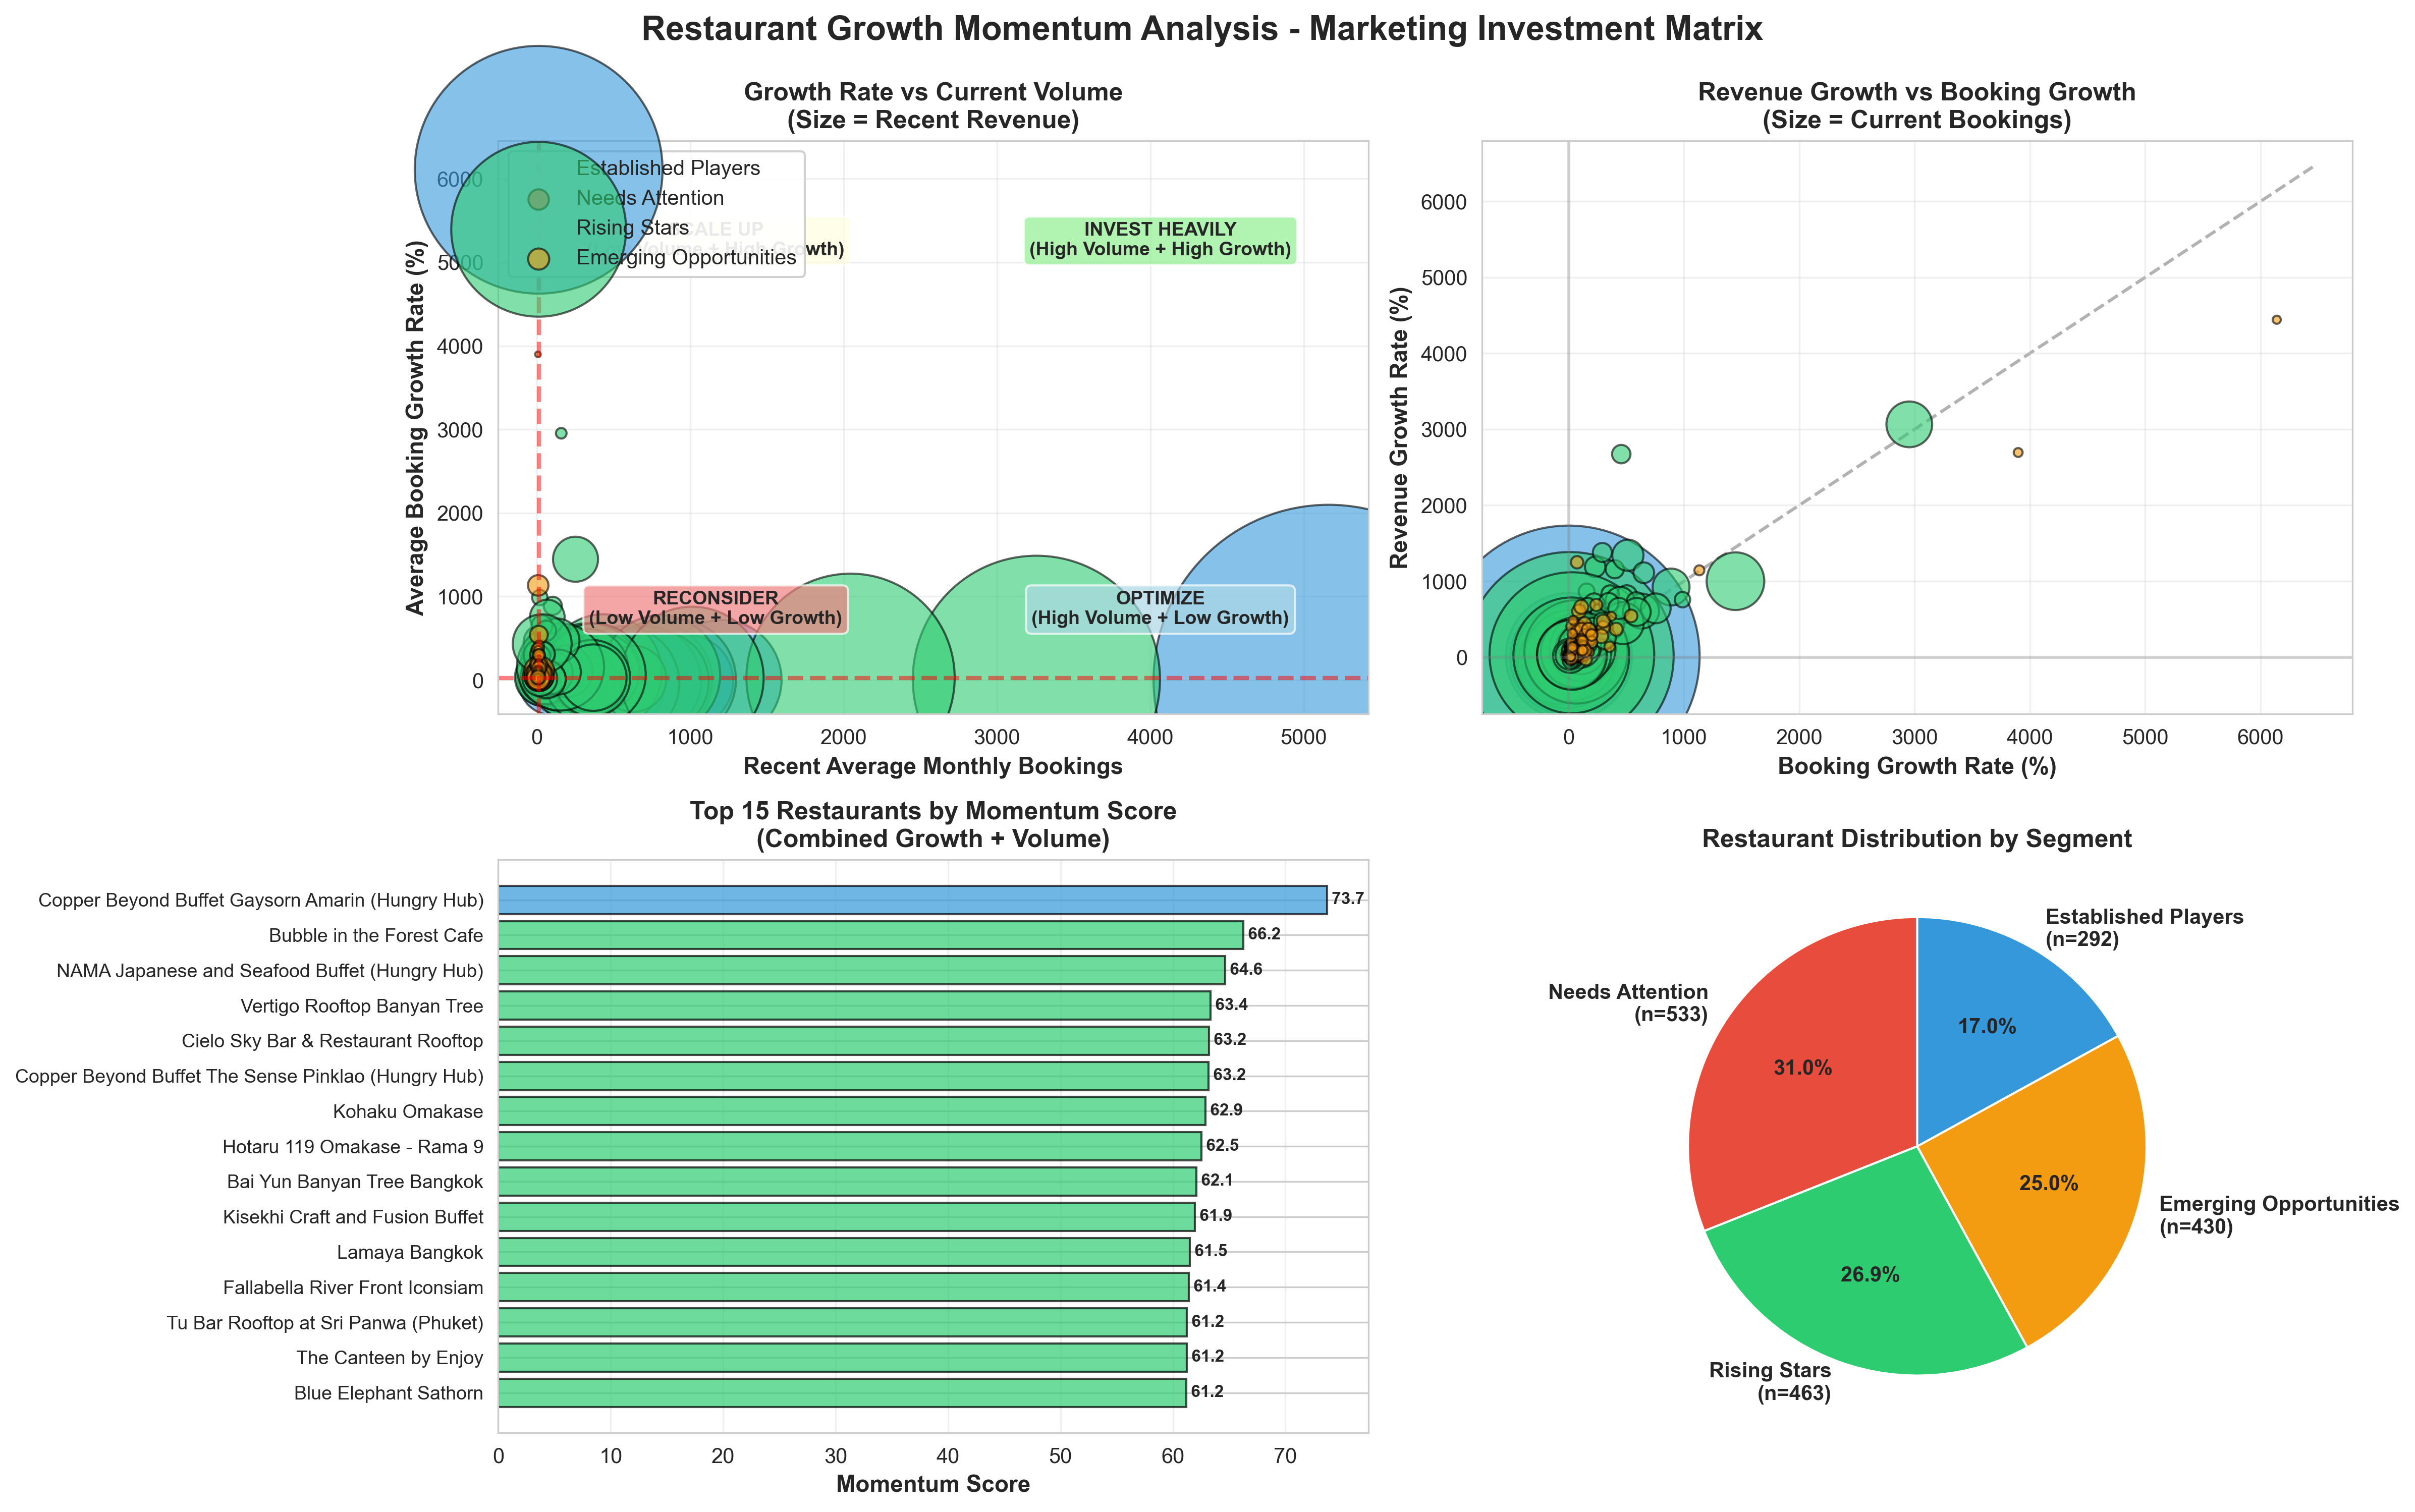

In [11]:
# Display the main growth matrix
from IPython.display import Image
Image(r'C:\Users\foogu\OneDrive\Documents\IS455 Data Analytics in Asia\growth_momentum_matrix.png')

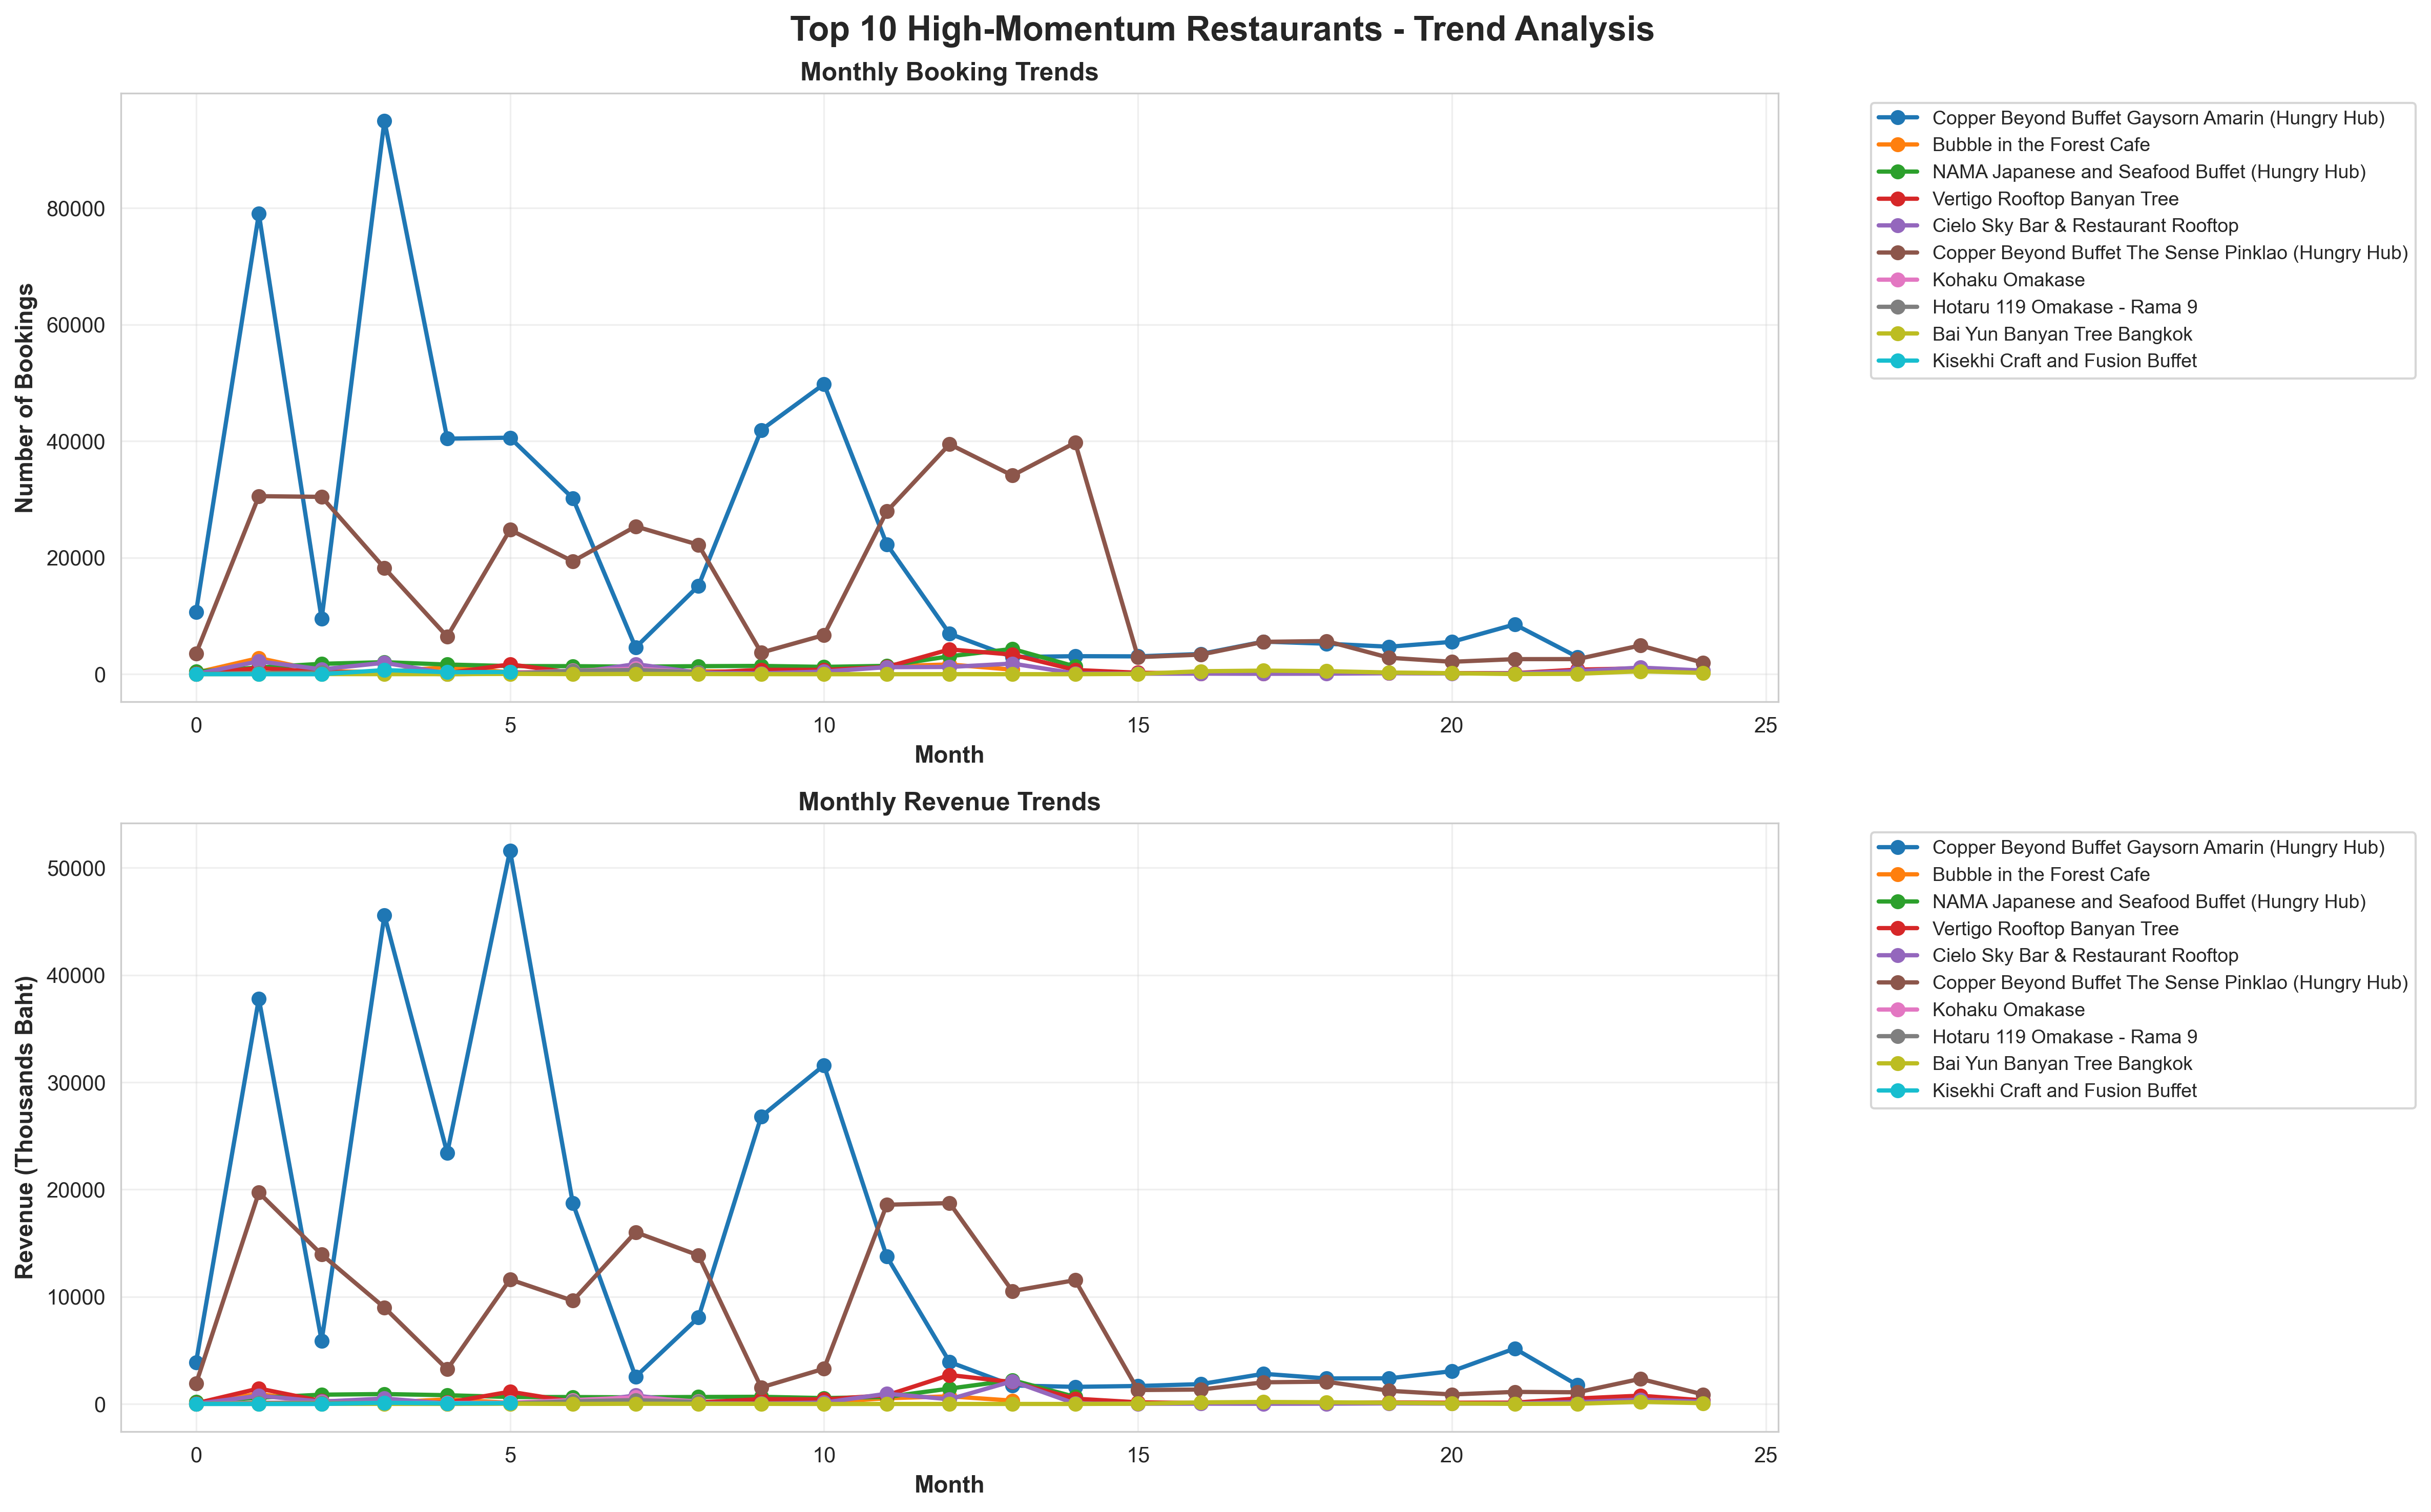

In [12]:
# Display trend analysis
Image(r'C:\Users\foogu\OneDrive\Documents\IS455 Data Analytics in Asia\top_performers_trends.png')

## Step 6: Export Investment Priority List

In [13]:
# Create a prioritized investment list
investment_priority = restaurant_summary.sort_values('momentum_score', ascending=False).copy()

# Add investment tier
def assign_tier(row):
    if row['segment'] == 'Rising Stars':
        return 'Tier 1 - Heavy Investment'
    elif row['segment'] == 'Emerging Opportunities':
        return 'Tier 2 - Scale Up'
    elif row['segment'] == 'Established Players':
        return 'Tier 3 - Maintain'
    else:
        return 'Tier 4 - Minimal Investment'

investment_priority['investment_tier'] = investment_priority.apply(assign_tier, axis=1)

# Save to CSV
investment_priority[[
    'name', 'investment_tier', 'segment', 'momentum_score',
    'avg_growth_rate', 'revenue_growth_rate', 'recent_avg_bookings',
    'recent_avg_revenue', 'total_bookings', 'total_revenue'
]].to_csv(r"C:\Users\foogu\OneDrive\Documents\IS455 Data Analytics in Asia\marketing_investment_priority.csv", index=False)

print("Investment priority list saved to: C:\\Users\\foogu\\OneDrive\\Documents\\IS455 Data Analytics in Asia\\marketing_investment_priority.csv")
print("\nPreview:")
display(investment_priority[[
    'name', 'investment_tier', 'momentum_score', 'avg_growth_rate'
]].head(20))

Investment priority list saved to: C:\Users\foogu\OneDrive\Documents\IS455 Data Analytics in Asia\marketing_investment_priority.csv

Preview:


,name,investment_tier,momentum_score,avg_growth_rate
579,Copper Beyond Buffet Gayso...,Tier 3 - Maintain,73.682357,2.025963
858,Bubble in the Forest Cafe,Tier 1 - Heavy Investment,66.238552,64.146251
837,NAMA Japanese and Seafood ...,Tier 1 - Heavy Investment,64.634724,28.580265
5,Vertigo Rooftop Banyan Tree,Tier 1 - Heavy Investment,63.353346,91.050341
418,Cielo Sky Bar & Restaurant...,Tier 1 - Heavy Investment,63.189553,97.838118
23,Copper Beyond Buffet The S...,Tier 1 - Heavy Investment,63.179182,10.065444
1189,Kohaku Omakase,Tier 1 - Heavy Investment,62.898487,64.931865
1184,Hotaru 119 Omakase - Rama 9,Tier 1 - Heavy Investment,62.539911,120.606040
10,Bai Yun Banyan Tree Bangkok,Tier 1 - Heavy Investment,62.073984,200.436168
1335,Kisekhi Craft and Fusion B...,Tier 1 - Heavy Investment,61.944498,1446.967567


## Step 7: Budget Allocation Recommendation

In [14]:
# Calculate recommended budget allocation
print("RECOMMENDED MARKETING BUDGET ALLOCATION")
print("=" * 100)
print()

tier_distribution = investment_priority['investment_tier'].value_counts().sort_index()

# Suggested budget splits
budget_allocation = {
    'Tier 1 - Heavy Investment': 0.50,  # 50% of budget
    'Tier 2 - Scale Up': 0.30,  # 30% of budget
    'Tier 3 - Maintain': 0.15,  # 15% of budget
    'Tier 4 - Minimal Investment': 0.05  # 5% of budget
}

print("If total marketing budget = 100%:\n")
for tier, pct in budget_allocation.items():
    count = tier_distribution.get(tier, 0)
    per_restaurant = (pct / count * 100) if count > 0 else 0
    print(f"{tier}:")
    print(f"  Total Allocation: {pct*100:.0f}%")
    print(f"  Number of Restaurants: {count}")
    print(f"  Budget per Restaurant: {per_restaurant:.2f}%")
    print()

RECOMMENDED MARKETING BUDGET ALLOCATION

If total marketing budget = 100%:

Tier 1 - Heavy Investment:
  Total Allocation: 50%
  Number of Restaurants: 463
  Budget per Restaurant: 0.11%

Tier 2 - Scale Up:
  Total Allocation: 30%
  Number of Restaurants: 430
  Budget per Restaurant: 0.07%

Tier 3 - Maintain:
  Total Allocation: 15%
  Number of Restaurants: 292
  Budget per Restaurant: 0.05%

Tier 4 - Minimal Investment:
  Total Allocation: 5%
  Number of Restaurants: 533
  Budget per Restaurant: 0.01%



## Summary

### Key Insights:

1. **Rising Stars** deserve the highest marketing investment - they're already performing well AND growing fast
2. **Emerging Opportunities** need visibility - invest to convert their growth momentum into volume
3. **Established Players** focus on retention and optimization rather than aggressive growth
4. **Needs Attention** restaurants require operational fixes before marketing investment

### Files Generated:
- `growth_momentum_matrix.png` - Visual analysis of all restaurants
- `top_performers_trends.png` - Time series of high-momentum restaurants
- `growth_analysis_report.txt` - Complete text report
- `restaurant_summary.csv` - Full restaurant metrics
- `monthly_metrics.csv` - Month-by-month performance data
- `marketing_investment_priority.csv` - Prioritized investment list

All files are saved in `/mnt/user-data/outputs/`